In [ ]:

%run "./02_EMS_preprocessing.ipynb"

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader as GeoDataLoader

if not GNN_GRAPHS_FILE.exists():
    raise FileNotFoundError(
        f"Fichier de graphes absent : {GNN_GRAPHS_FILE}"
    )

try:
    graph_data = torch.load(
        GNN_GRAPHS_FILE,
        map_location="cpu",
        weights_only=False,
    )
except TypeError:
    graph_data = torch.load(
        GNN_GRAPHS_FILE,
        map_location="cpu",
    )

graphs_train = graph_data["train"]
graphs_val = graph_data["validation"]
graphs_test = graph_data["test"]

print("Train      :", len(graphs_train))
print("Validation :", len(graphs_val))
print("Test       :", len(graphs_test))
print("Dimension  :", graph_data["input_dim"])


ROOT_DIR  : C:\Users\Admin\Desktop\Projet_Artemis2
DATA_FILE : C:\Users\Admin\Desktop\Projet_Artemis2\data\Artemis.csv | existe: True
RANDOM_SEED: 42 | DEVICE: cuda
CONFIGURATION DU PROJET HESS

BATTERIE ÉNERGIE
Énergie          : 13709.89 Wh
Tension          : 450.00 V
Capacité         : 30.4664 Ah
Masse            : 55.12 kg
Courant recharge : -14.00 A
Courant décharge : 28.00 A
Configuration    : 125S7P

BATTERIE PUISSANCE
Énergie          : 2987.12 Wh
Tension          : 402.60 V
Capacité         : 7.4196 Ah
Masse            : 50.02 kg
Courant recharge : -130.00 A
Courant décharge : 400.00 A
Configuration    : 122S2P

HESS
Énergie totale   : 16697.01 Wh
Masse totale     : 105.14 kg
Tension du bus   : 402.60 V
Puissance min    : -58638.00 W
Puissance max    : 173640.00 W

MODÈLES
LSTM seul        : 7 → 64 → 3
LSTM NS          : 15 → 64 → 3
GNN simple       : 12 → 32 → 1
MLP simple       : 5 → 64 → 32 → 1
MLP NS           : 17 → 64 → 32 → 1

Device           : cuda
Fichier          : 

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train      : 5924
Validation : 3113
Test       : 3066
Dimension  : 12


Verification des graphes

In [ ]:
if graph_data["input_dim"] != GNN_INPUT_DIM:
    raise ValueError(
        f"Dimension enregistrée : {graph_data['input_dim']}, "
        f"dimension configurée : {GNN_INPUT_DIM}"
    )

graph_sets = {
    "train": graphs_train,
    "validation": graphs_val,
    "test": graphs_test,
}

for split_name, graphs in graph_sets.items():
    if len(graphs) == 0:
        raise ValueError(f"Aucun graphe dans {split_name}.")

    for graph in graphs:
        if graph.x.shape != (
            len(GNN_NODE_NAMES),
            GNN_INPUT_DIM,
        ):
            raise ValueError(
                f"Forme incorrecte dans {split_name} : "
                f"{graph.x.shape}"
            )

        if not torch.isfinite(graph.x).all():
            raise ValueError(
                f"Caractéristiques non finies dans {split_name}."
            )

        if not torch.isfinite(graph.y).all():
            raise ValueError(
                f"Cible non finie dans {split_name}."
            )

print("Graphes validés.")

Graphes validés.


Vérification de la normalisation existante


In [ ]:
n_continuous = len(
    GNN_CONTINUOUS_FEATURE_NAMES
)

train_x = torch.cat(
    [graph.x for graph in graphs_train],
    dim=0,
)

continuous_x = train_x[:, :n_continuous]
node_types = train_x[:, n_continuous:]

print(
    "Moyenne features continues :",
    continuous_x.mean(dim=0),
)

print(
    "Écart-type features continues :",
    continuous_x.std(dim=0),
)

print(
    "Valeurs type de nœud :",
    torch.unique(node_types),
)

if node_types.min() < 0 or node_types.max() > 1:
    raise ValueError(
        "Encodage des types de nœuds incorrect."
    )

if not GNN_SCALER_FILE.exists():
    raise FileNotFoundError(
        f"Scalers absents : {GNN_SCALER_FILE}"
    )

print("Normalisation :", GNN_SCALER_FILE)

Moyenne features continues : tensor([ 3.5030e-08, -1.1229e-08,  1.8312e-09, -5.7914e-09,  5.7623e-09,
        -5.1515e-10, -2.8977e-09])
Écart-type features continues : tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Valeurs type de nœud : tensor([0., 1.])
Normalisation : C:\Users\Admin\Desktop\Projet_Artemis2\models\gnn_node_scalers.npz


DataLoaders

In [ ]:

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = GeoDataLoader(
    graphs_train,
    batch_size=GNN_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    generator=generator,
)

val_loader = GeoDataLoader(
    graphs_val,
    batch_size=GNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = GeoDataLoader(
    graphs_test,
    batch_size=GNN_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(
    len(train_loader.dataset),
    len(val_loader.dataset),
    len(test_loader.dataset),
)

5924 3113 3066


Modèle GNN simple

In [ ]:

class GNNSimple(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_layers,
        dropout,
    ):
        super().__init__()

        if num_layers < 1:
            raise ValueError(
                "GNN_NUM_LAYERS doit être supérieur ou égal à 1."
            )

        self.convs = nn.ModuleList()

        self.convs.append(
            GCNConv(input_dim, hidden_dim)
        )

        for _ in range(num_layers - 1):
            self.convs.append(
                GCNConv(hidden_dim, hidden_dim)
            )

        self.dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(
        self,
        x,
        edge_index,
        batch,
    ):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = torch.relu(x)
            x = self.dropout(x)

        graph_embedding = global_mean_pool(
            x,
            batch,
        )

        return self.head(
            graph_embedding
        ).squeeze(-1)


torch.manual_seed(RANDOM_SEED)

model = GNNSimple(
    input_dim=GNN_INPUT_DIM,
    hidden_dim=GNN_HIDDEN_SIZE,
    num_layers=GNN_NUM_LAYERS,
    dropout=GNN_DROPOUT,
).to(DEVICE)

print(model)
print(
    "Device :",
    next(model.parameters()).device,
)

GNNSimple(
  (convs): ModuleList(
    (0): GCNConv(12, 32)
    (1): GCNConv(32, 32)
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
    (4): Sigmoid()
  )
)
Device : cuda:0


 Entraînement

In [ ]:

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=GNN_LEARNING_RATE,
)

best_val = float("inf")
best_epoch = -1
patience_count = 0

history = {
    "train": [],
    "validation": [],
}

for epoch in range(GNN_EPOCHS):
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch = batch.to(
            DEVICE,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        prediction = model(
            batch.x,
            batch.edge_index,
            batch.batch,
        )

        target = batch.y.view(-1)

        loss = criterion(
            prediction,
            target,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        train_loss += (
            loss.item()
            * batch.num_graphs
        )

    train_loss /= len(
        train_loader.dataset
    )

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(
                DEVICE,
                non_blocking=True,
            )

            prediction = model(
                batch.x,
                batch.edge_index,
                batch.batch,
            )

            target = batch.y.view(-1)

            loss = criterion(
                prediction,
                target,
            )

            val_loss += (
                loss.item()
                * batch.num_graphs
            )

    val_loss /= len(
        val_loader.dataset
    )

    if not np.isfinite(train_loss):
        raise ValueError(
            "Train loss non finie."
        )

    if not np.isfinite(val_loss):
        raise ValueError(
            "Validation loss non finie."
        )

    history["train"].append(train_loss)
    history["validation"].append(val_loss)

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_epoch = epoch
        patience_count = 0

        torch.save(
            model.state_dict(),
            GNN_CHECKPOINT,
        )
    else:
        patience_count += 1

    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{GNN_EPOCHS} "
            f"train={train_loss:.6f} "
            f"val={val_loss:.6f} "
            f"patience={patience_count}"
        )

    if patience_count >= GNN_PATIENCE:
        print(
            f"Arrêt anticipé à l'époque "
            f"{epoch + 1}."
        )
        break

Epoch   1/100 train=0.118465 val=0.043939 patience=0
Epoch   5/100 train=0.003603 val=0.001348 patience=0
Epoch  10/100 train=0.001484 val=0.000354 patience=0
Epoch  15/100 train=0.001037 val=0.000205 patience=0
Epoch  20/100 train=0.000820 val=0.000126 patience=0
Epoch  25/100 train=0.000659 val=0.000115 patience=1
Epoch  30/100 train=0.000571 val=0.000076 patience=0
Epoch  35/100 train=0.000509 val=0.000080 patience=2
Epoch  40/100 train=0.000448 val=0.000065 patience=1
Epoch  45/100 train=0.000437 val=0.000068 patience=3
Epoch  50/100 train=0.000440 val=0.000059 patience=4
Epoch  55/100 train=0.000379 val=0.000095 patience=1
Epoch  60/100 train=0.000386 val=0.000033 patience=2
Epoch  65/100 train=0.000371 val=0.000021 patience=0
Epoch  70/100 train=0.000357 val=0.000031 patience=5
Epoch  75/100 train=0.000287 val=0.000068 patience=10
Epoch  80/100 train=0.000293 val=0.000025 patience=15
Arrêt anticipé à l'époque 80.


Chargement du meilleur modèle

In [ ]:
if not GNN_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Checkpoint absent : {GNN_CHECKPOINT}"
    )

try:
    state_dict = torch.load(
        GNN_CHECKPOINT,
        map_location=DEVICE,
        weights_only=True,
    )
except TypeError:
    state_dict = torch.load(
        GNN_CHECKPOINT,
        map_location=DEVICE,
    )

model.load_state_dict(state_dict)

print("Meilleure époque :", best_epoch + 1)
print("Meilleure val loss :", best_val)

Meilleure époque : 65
Meilleure val loss : 2.0781584614049966e-05


Courbes d’apprentissage

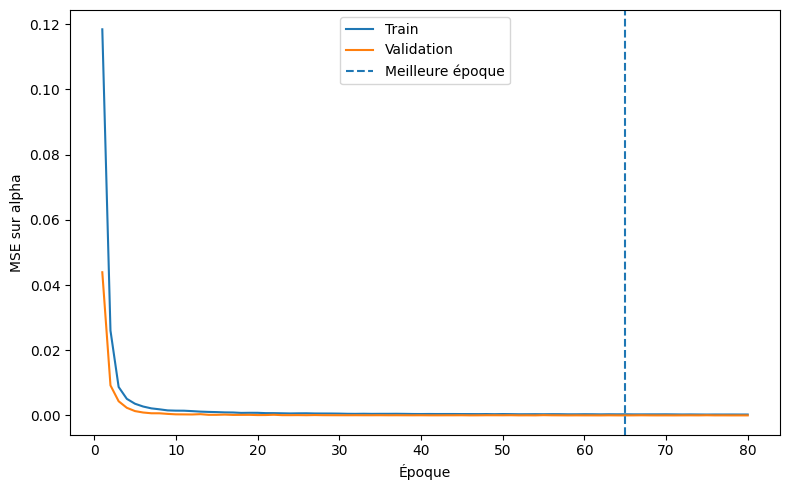

In [ ]:

history_df = pd.DataFrame({
    "epoch": np.arange(
        1,
        len(history["train"]) + 1,
    ),
    "train_loss": history["train"],
    "val_loss": history["validation"],
})

history_df.to_csv(
    TABLES_DIR
    / "gnn_simple_training_history.csv",
    index=False,
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation",
)

plt.axvline(
    best_epoch + 1,
    linestyle="--",
    label="Meilleure époque",
)

plt.xlabel("Époque")
plt.ylabel("MSE sur alpha")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gnn_simple_loss_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Métriques

In [ ]:

def mae(y_true, y_pred):
    return float(
        np.mean(
            np.abs(y_true - y_pred)
        )
    )


def rmse(y_true, y_pred):
    return float(
        np.sqrt(
            np.mean(
                (y_true - y_pred) ** 2
            )
        )
    )


def r2_score_np(y_true, y_pred):
    denominator = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if np.isclose(denominator, 0.0):
        return np.nan

    numerator = np.sum(
        (y_true - y_pred) ** 2
    )

    return float(
        1.0 - numerator / denominator
    )


def predict_gnn(model, loader):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(
                DEVICE,
                non_blocking=True,
            )

            output = model(
                batch.x,
                batch.edge_index,
                batch.batch,
            )

            predictions.append(
                output.cpu().numpy()
            )

            targets.append(
                batch.y.view(-1)
                .cpu()
                .numpy()
            )

    return (
        np.concatenate(predictions),
        np.concatenate(targets),
    )

Comparaison avec une baseline constante

In [ ]:
alpha_train = np.array(
    [
        graph.y.item()
        for graph in graphs_train
    ],
    dtype=np.float32,
)

alpha_mean_train = float(
    alpha_train.mean()
)

evaluation_loaders = {
    "train": train_loader,
    "validation": val_loader,
    "test": test_loader,
}

predictions = {}
metrics_rows = []

for split_name, loader in evaluation_loaders.items():
    alpha_pred, alpha_true = predict_gnn(
        model,
        loader,
    )

    predictions[split_name] = {
        "pred": alpha_pred,
        "true": alpha_true,
    }

    constant_pred = np.full_like(
        alpha_true,
        alpha_mean_train,
    )

    metrics_rows.append({
        "split": split_name,
        "model": "GNN simple",
        "mae": mae(alpha_true, alpha_pred),
        "rmse": rmse(alpha_true, alpha_pred),
        "r2": r2_score_np(alpha_true, alpha_pred),
    })

    metrics_rows.append({
        "split": split_name,
        "model": "Moyenne train",
        "mae": mae(alpha_true, constant_pred),
        "rmse": rmse(alpha_true, constant_pred),
        "r2": r2_score_np(alpha_true, constant_pred),
    })

metrics_df = pd.DataFrame(
    metrics_rows
)

display(metrics_df)

metrics_df.to_csv(
    TABLES_DIR
    / "gnn_simple_metrics.csv",
    index=False,
)

print(
    "Moyenne alpha train :",
    alpha_mean_train,
)

,split,model,mae,rmse,r2
0,train,GNN simple,0.002647,0.004679,9.995034e-01
1,train,Moyenne train,0.161026,0.209956,-1.192093e-07
2,validation,GNN simple,0.002553,0.004559,9.995545e-01
3,validation,Moyenne train,0.164901,0.216108,-1.108885e-03
4,test,GNN simple,0.106651,0.308591,2.349468e-01
5,test,Moyenne train,0.252333,0.369915,-9.932935e-02


Moyenne alpha train : 0.11131592839956284


Métadonnées du test

In [ ]:
test_file = (
    PROCESSED_DIR
    / "test_with_baselines.csv"
)

if not test_file.exists():
    raise FileNotFoundError(
        f"Fichier absent : {test_file}"
    )

test_df = pd.read_csv(
    test_file
)

test_indices = np.array(
    [
        int(graph.sample_index.item())
        for graph in graphs_test
    ],
    dtype=int,
)

meta_test = (
    test_df.iloc[test_indices]
    .copy()
    .reset_index(drop=True)
)

alpha_gnn_test = predictions["test"]["pred"]
alpha_hist_test = predictions["test"]["true"]

if len(meta_test) != len(alpha_gnn_test):
    raise ValueError(
        "Métadonnées et prédictions non alignées."
    )

if not np.allclose(
    meta_test["alpha_ems_eb_priority"].to_numpy(),
    alpha_hist_test,
    atol=1e-6,
):
    raise ValueError(
        "Les cibles alpha_hist ne sont pas alignées."
    )

print("Alignement vérifié :", len(meta_test))

Alignement vérifié : 3066


Sauvegarde

In [ ]:
pred_df = meta_test[
    [
        TIME_COL,
        "SOC_EB",
        "SOC_PB",
        "hasPower",
        "hasAcceleration",
        "alpha_ems_eb_priority",
    ]
].copy()

pred_df["alpha_ems_gnn"] = alpha_gnn_test

pred_df["P_PB_ems_eb_priority"] = (
    pred_df["alpha_ems_eb_priority"]
    * pred_df["hasPower"]
)

pred_df["P_EB_ems_eb_priority"] = (
    1.0 - pred_df["alpha_ems_eb_priority"]
) * pred_df["hasPower"]

pred_df["P_EB_ems_gnn"] = (
    pred_df["alpha_ems_gnn"]
    * pred_df["hasPower"]
)

pred_df["P_EB_ems_gnn"] = (
    1.0 - pred_df["alpha_ems_gnn"]
) * pred_df["hasPower"]

pred_df["alpha_error"] = (
    pred_df["alpha_ems_gnn"]
    - pred_df["alpha_ems_eb_priority"]
)

prediction_file = (
    PREDICTIONS_DIR
    / "predictions_gnn_simple.csv"
)

pred_df.to_csv(
    prediction_file,
    index=False,
)

print("Prédictions :", prediction_file)
print("Checkpoint :", GNN_CHECKPOINT)
print("Normalisation :", GNN_SCALER_FILE)


Prédictions : C:\Users\Admin\Desktop\Projet_Artemis2\results\predictions\predictions_gnn_simple.csv
Checkpoint : C:\Users\Admin\Desktop\Projet_Artemis2\models\checkpoints\EMS_GNN.pt
Normalisation : C:\Users\Admin\Desktop\Projet_Artemis2\models\gnn_node_scalers.npz


Prédictions contre cible




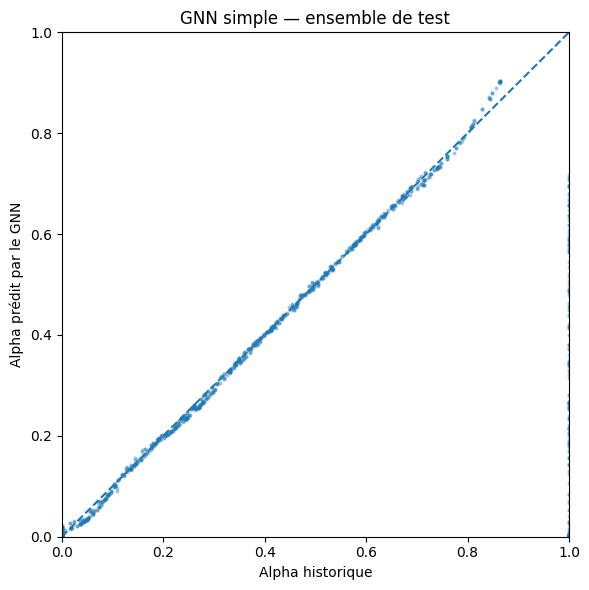

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(
    alpha_hist_test,
    alpha_gnn_test,
    s=4,
    alpha=0.3,
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Alpha historique")
plt.ylabel("Alpha prédit par le GNN")
plt.title("GNN simple — ensemble de test")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "gnn_simple_pred_vs_hist.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()